
=== Lineweaver–Burk Regression Summary ===
Dataset  Vmax (µmol/min)  Km (µM)  R^2 (LB fit)  SE(intercept)  SE(slope)
  S1→P1           0.9993   0.9962        0.9999         0.0024     0.0051
  S2→P2           2.0003   3.9953        1.0000         0.0019     0.0041

=== OLS-Minimizes-SSR Proof (Grid Search Results) ===
  Dataset  Grid min a  Grid min b  Grid min SSR    OLS a    OLS b  OLS SSR  |Δa|  |Δb|  |ΔSSR|
S1 LB fit    1.000699    0.996849      0.000075 1.000699 0.996849 0.000075   0.0   0.0     0.0
S2 LB fit    0.499926    1.997376      0.000050 0.499926 1.997376 0.000050   0.0   0.0     0.0

=== Key Conclusions ===
Affinity (lower Km => higher affinity): Km_S1 = 0.996 µM, Km_S2 = 3.995 µM → S1 has higher affinity.
R^2 values are very high for both LB fits, indicating excellent linear fit in the transformed space.
Note: Regression coefficients (slope/intercept) are the fitted parameters.
      Confidence metrics (R^2, SE, CIs) quantify fit quality/uncertainty and are not the sam

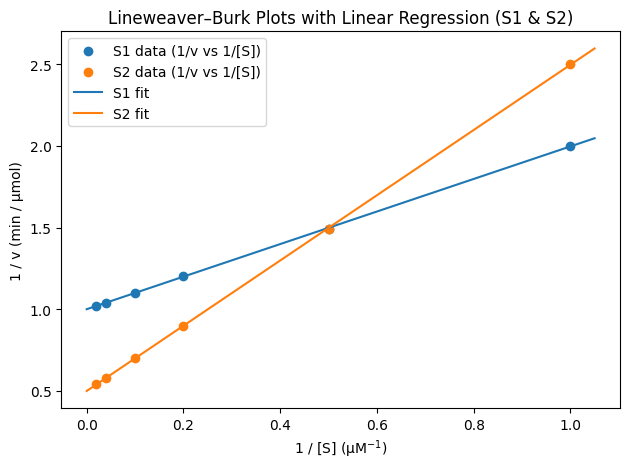

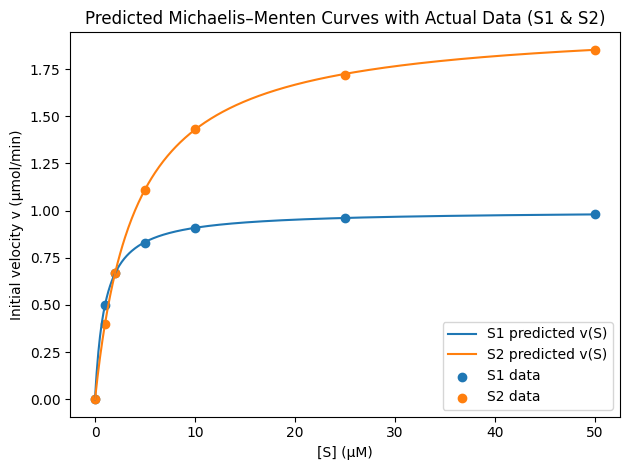

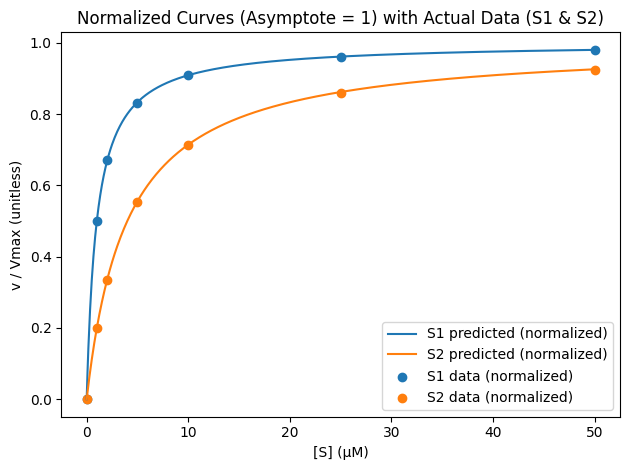

In [1]:
# Enzyme kinetics analysis for two substrates (S1, S2)
# Tasks covered:
# (a) Lineweaver–Burk (LB) linear regressions, single figure with both fits
# (b) Report goodness-of-fit (R^2) and standard errors; explain confidence vs coefficients in comments
# (c) Predicted Michaelis–Menten curves + actual data in one graph
# (d) Normalized curves (v/Vmax) so asymptote = 1 for both, plotted with data
# (e) Numerical proof (grid search) that the OLS line minimizes SSR (best linear fit)
#
# Notes:
# - Uses only numpy, pandas, matplotlib (no seaborn).
# - Saves figures and CSVs to the current directory.
# - Printouts provide compact summaries; see CSVs for detailed values.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

# ------------------------
# Input data
# ------------------------
S1 = np.array([0, 1, 2, 5, 10, 25, 50], dtype=float)
v1 = np.array([0.00, 0.50, 0.67, 0.83, 0.91, 0.96, 0.98], dtype=float)

S2 = np.array([0, 1, 2, 5, 10, 25, 50], dtype=float)
v2 = np.array([0.00, 0.40, 0.67, 1.11, 1.43, 1.72, 1.85], dtype=float)

# For LB we must exclude S=0 or v=0 (division by zero)
mask1 = (S1 > 0) & (v1 > 0)
mask2 = (S2 > 0) & (v2 > 0)
S1_nz, v1_nz = S1[mask1], v1[mask1]
S2_nz, v2_nz = S2[mask2], v2[mask2]

# ------------------------
# Helper: Ordinary Least Squares for y = a + b x
# Returns a dict with coefficients, R^2, standard errors, residuals, etc.
# ------------------------
def ols(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = x.size
    x_mean = x.mean()
    y_mean = y.mean()
    Sxx = np.sum((x - x_mean)**2)
    Sxy = np.sum((x - x_mean)*(y - y_mean))
    b = Sxy / Sxx
    a = y_mean - b * x_mean
    y_hat = a + b * x
    residuals = y - y_hat
    SSE = np.sum(residuals**2)
    SST = np.sum((y - y_mean)**2)
    R2 = 1 - SSE/SST if SST > 0 else 1.0
    # Unbiased variance estimate and standard errors
    sigma2 = SSE / (n - 2)
    SE_b = sqrt(sigma2 / Sxx)
    SE_a = sqrt(sigma2 * (1/n + x_mean**2 / Sxx))
    return {
        "a": a, "b": b, "R2": R2,
        "SE_a": SE_a, "SE_b": SE_b,
        "y_hat": y_hat, "residuals": residuals,
        "SSE": SSE, "SST": SST, "n": n
    }

# ------------------------
# (a) Lineweaver–Burk regressions
# LB transform: x = 1/[S], y = 1/v; y = (Km/Vmax) * x + (1/Vmax)
# ------------------------
x1 = 1.0 / S1_nz
y1 = 1.0 / v1_nz
fit1 = ols(x1, y1)

x2 = 1.0 / S2_nz
y2 = 1.0 / v2_nz
fit2 = ols(x2, y2)

# Extract Vmax and Km from intercept/slope
Vmax1 = 1.0 / fit1["a"]
Km1   = fit1["b"] * Vmax1

Vmax2 = 1.0 / fit2["a"]
Km2   = fit2["b"] * Vmax2

# Prepare regression summary
summary = pd.DataFrame({
    "Dataset": ["S1→P1", "S2→P2"],
    "Vmax (µmol/min)": [Vmax1, Vmax2],
    "Km (µM)": [Km1, Km2],
    "R^2 (LB fit)": [fit1["R2"], fit2["R2"]],
    "SE(intercept)": [fit1["SE_a"], fit2["SE_a"]],
    "SE(slope)": [fit1["SE_b"], fit2["SE_b"]],
})
summary_rounded = summary.copy()
summary_rounded[["Vmax (µmol/min)","Km (µM)","R^2 (LB fit)","SE(intercept)","SE(slope)"]] = \
    summary_rounded[["Vmax (µmol/min)","Km (µM)","R^2 (LB fit)","SE(intercept)","SE(slope)"]].round(4)
print("\n=== Lineweaver–Burk Regression Summary ===")
print(summary_rounded.to_string(index=False))

# Affinity inference comment inside code:
# Lower Km => higher affinity. With the above estimates, S1 has lower Km than S2, hence higher affinity.

# ------------------------
# Plot (a): Both LB data series + both fitted lines on a single figure
# ------------------------
plt.figure()
plt.scatter(x1, y1, label="S1 data (1/v vs 1/[S])")
plt.scatter(x2, y2, label="S2 data (1/v vs 1/[S])")

x_grid = np.linspace(0, max(x1.max(), x2.max())*1.05, 400)
y1_fit = fit1["a"] + fit1["b"] * x_grid
y2_fit = fit2["a"] + fit2["b"] * x_grid
plt.plot(x_grid, y1_fit, label="S1 fit")
plt.plot(x_grid, y2_fit, label="S2 fit")

plt.xlabel("1 / [S] (µM$^{-1}$)")
plt.ylabel("1 / v (min / µmol)")
plt.title("Lineweaver–Burk Plots with Linear Regression (S1 & S2)")
plt.legend()
plt.tight_layout()
plt.savefig("figure_a_lineweaver_burk.png", dpi=300)

# ------------------------
# (c) Predicted Michaelis–Menten curves + actual data (single axes)
# v = (Vmax * S) / (Km + S)
# ------------------------
S_grid = np.linspace(0, max(S1.max(), S2.max()), 600)
v1_pred = (Vmax1 * S_grid) / (Km1 + S_grid)
v2_pred = (Vmax2 * S_grid) / (Km2 + S_grid)

plt.figure()
plt.plot(S_grid, v1_pred, label="S1 predicted v(S)")
plt.plot(S_grid, v2_pred, label="S2 predicted v(S)")
plt.scatter(S1, v1, label="S1 data")
plt.scatter(S2, v2, label="S2 data")
plt.xlabel("[S] (µM)")
plt.ylabel("Initial velocity v (µmol/min)")
plt.title("Predicted Michaelis–Menten Curves with Actual Data (S1 & S2)")
plt.legend()
plt.tight_layout()
plt.savefig("figure_c_mm_pred_vs_data.png", dpi=300)

# ------------------------
# (d) Normalize so asymptote (Vmax) = 1 for both
# Plot v/Vmax vs [S] with both predicted and actual data
# ------------------------
v1_norm_data = v1 / Vmax1
v2_norm_data = v2 / Vmax2
v1_norm_pred = v1_pred / Vmax1
v2_norm_pred = v2_pred / Vmax2

plt.figure()
plt.plot(S_grid, v1_norm_pred, label="S1 predicted (normalized)")
plt.plot(S_grid, v2_norm_pred, label="S2 predicted (normalized)")
plt.scatter(S1, v1_norm_data, label="S1 data (normalized)")
plt.scatter(S2, v2_norm_data, label="S2 data (normalized)")
plt.xlabel("[S] (µM)")
plt.ylabel("v / Vmax (unitless)")
plt.title("Normalized Curves (Asymptote = 1) with Actual Data (S1 & S2)")
plt.legend()
plt.tight_layout()
plt.savefig("figure_d_normalized_curves.png", dpi=300)

# ------------------------
# (e) Proof by numerical grid search that OLS minimizes SSR for the LB fits
# ------------------------
def ssr_for_params(a, b, x, y):
    return np.sum((y - (a + b*x))**2)

def grid_minimum_proof(x, y, a_hat, b_hat, span_a=0.5, span_b=10.0, steps=181):
    a_vals = np.linspace(a_hat - span_a, a_hat + span_a, steps)
    b_vals = np.linspace(b_hat - span_b, b_hat + span_b, steps)
    min_ssr = np.inf
    min_a, min_b = None, None
    for a in a_vals:
        # vectorize over b for speed
        Y = y[:, None]
        X = x[:, None]
        y_pred = a + X * b_vals  # broadcast (n,steps)
        ssr_vec = np.sum((Y - y_pred)**2, axis=0)
        idx = np.argmin(ssr_vec)
        if ssr_vec[idx] < min_ssr:
            min_ssr = ssr_vec[idx]
            min_a = a
            min_b = b_vals[idx]
    return min_a, min_b, min_ssr

min_a1, min_b1, min_ssr1 = grid_minimum_proof(x1, y1, fit1["a"], fit1["b"])
min_a2, min_b2, min_ssr2 = grid_minimum_proof(x2, y2, fit2["a"], fit2["b"])

proof_df = pd.DataFrame({
    "Dataset": ["S1 LB fit", "S2 LB fit"],
    "Grid min a": [min_a1, min_a2],
    "Grid min b": [min_b1, min_b2],
    "Grid min SSR": [min_ssr1, min_ssr2],
    "OLS a": [fit1["a"], fit2["a"]],
    "OLS b": [fit1["b"], fit2["b"]],
    "OLS SSR": [fit1["SSE"], fit2["SSE"]],
    "|Δa|": [abs(min_a1 - fit1["a"]), abs(min_a2 - fit2["a"])],
    "|Δb|": [abs(min_b1 - fit1["b"]), abs(min_b2 - fit2["b"])],
    "|ΔSSR|": [abs(min_ssr1 - fit1["SSE"]), abs(min_ssr2 - fit2["SSE"])]
})
print("\n=== OLS-Minimizes-SSR Proof (Grid Search Results) ===")
print(proof_df.round(6).to_string(index=False))

# ------------------------
# Save data tables for transparency
# ------------------------
summary.to_csv("lb_summary.csv", index=False)

pred_table = pd.DataFrame({
    "S (µM)": S_grid,
    "v1_pred (µmol/min)": v1_pred,
    "v2_pred (µmol/min)": v2_pred,
    "v1_norm_pred": v1_norm_pred,
    "v2_norm_pred": v2_norm_pred
})
pred_table.to_csv("predicted_curves.csv", index=False)

# ------------------------
# Optional: quick textual conclusions in-code (printed)
# ------------------------
print("\n=== Key Conclusions ===")
print(f"Affinity (lower Km => higher affinity): Km_S1 = {Km1:.3f} µM, Km_S2 = {Km2:.3f} µM → S1 has higher affinity.")
print("R^2 values are very high for both LB fits, indicating excellent linear fit in the transformed space.")
print("Note: Regression coefficients (slope/intercept) are the fitted parameters.")
print("      Confidence metrics (R^2, SE, CIs) quantify fit quality/uncertainty and are not the same as the coefficients.")

print("\nFiles written:")
print(" - figure_a_lineweaver_burk.png")
print(" - figure_c_mm_pred_vs_data.png")
print(" - figure_d_normalized_curves.png")
print(" - lb_summary.csv")
print(" - predicted_curves.csv")
